In [8]:
import numpy as np
import pymatching
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ============================================================
# 1. Define Stabilizer Geometry explicitly
# ============================================================

z_stabilizers_map = {
    0: [5, 6],
    1: [0, 1, 4, 5],
    2: [3, 4, 7, 8],
    3: [2, 3]
}

x_stabilizers_map = {
    0: [0, 1],
    1: [1, 2, 3, 4],
    2: [4, 5, 6, 7],
    3: [7, 8]
}

# ============================================================
# 2. Automated Graph Builder (Fixed for Contiguous IDs)
# ============================================================

def build_matching_graph(stabilizers_map, num_data_qubits):
    matching = pymatching.Matching()
    
    # Map each physical data qubit to the stabilizers it belongs to
    qubit_to_stabilizers = {q: [] for q in range(num_data_qubits)}
    for stab_idx, qubits in stabilizers_map.items():
        for q in qubits:
            qubit_to_stabilizers[q].append(stab_idx)
            
    boundary_nodes = set()
    next_boundary_id = len(stabilizers_map) # Start boundary IDs right after stabilizers (e.g., 4, 5...)
    
    for q, incident_stabilizers in qubit_to_stabilizers.items():
        if len(incident_stabilizers) == 2:
            node_a, node_b = incident_stabilizers[0], incident_stabilizers[1]
            matching.add_edge(node_a, node_b, fault_ids=q)
            
        elif len(incident_stabilizers) == 1:
            node_a = incident_stabilizers[0]
            unique_boundary_id = next_boundary_id
            next_boundary_id += 1
            
            matching.add_edge(node_a, unique_boundary_id, fault_ids=q)
            boundary_nodes.add(unique_boundary_id)
            
    if boundary_nodes:
        matching.set_boundary_nodes(boundary_nodes)
            
    return matching

# Build the decoders dynamically
matching_z = build_matching_graph(z_stabilizers_map, num_data_qubits=9)
matching_x = build_matching_graph(x_stabilizers_map, num_data_qubits=9)

print("✅ Automated PyMatching graphs successfully built dynamically!")

# ============================================================
# 3. Create Full Two-Round Qiskit Circuit Layout
# ============================================================

def create_two_round_circuit(errors=None):
    qc = QuantumCircuit(17, 16) 
    
    # --- ROUND 1: Base State Projection ---
    for idx, qubits in z_stabilizers_map.items():
        for q in qubits: qc.cx(q, 9 + idx)
    for idx, qubits in x_stabilizers_map.items():
        qc.h(13 + idx)
        for q in qubits: qc.cx(13 + idx, q)
        qc.h(13 + idx)
        
    for i in range(4): qc.measure(9 + i, i)       
    for i in range(4): qc.measure(13 + i, 4 + i)  
    
    for i in range(9, 17): qc.reset(i)
    qc.barrier()
    
    # --- SIMULATED FAULT LAYER ---
    if errors:
        for qubit, error_type in errors.items():
            if error_type == "X": qc.x(qubit)
            elif error_type == "Z": qc.z(qubit)
            elif error_type == "Y": qc.y(qubit)
    qc.barrier()
    
    # --- ROUND 2: Post-Fault Snapshot ---
    for idx, qubits in z_stabilizers_map.items():
        for q in qubits: qc.cx(q, 9 + idx)
    for idx, qubits in x_stabilizers_map.items():
        qc.h(13 + idx)
        for q in qubits: qc.cx(13 + idx, q)
        qc.h(13 + idx)
        
    for i in range(4): qc.measure(9 + i, 8 + i)    
    for i in range(4): qc.measure(13 + i, 12 + i)  
    
    return qc

# ============================================================
# 4. Pipeline Execution Logic (Fixed String Parsing Layout)
# ============================================================

def process_errors_with_pymatching(errors):
    print(f"\n================ Injected Profile: {errors} ================")
    
    qc = create_two_round_circuit(errors)
    counts = AerSimulator().run(qc, shots=1).result().get_counts()
    
    # FIX: Isolate the single string out of the dict key first, THEN reverse it character-by-character
    raw_string = list(counts.keys())[0]
    bitstring = raw_string[::-1] 
    
    # Safely slice out the individual measurement components
    round1_z = [int(b) for b in bitstring[0:4]]
    round1_x = [int(b) for b in bitstring[4:8]]
    round2_z = [int(b) for b in bitstring[8:12]]
    round2_x = [int(b) for b in bitstring[12:16]]
    
    # Delta Syndrome evaluation
    delta_z = np.array([r1 ^ r2 for r1, r2 in zip(round1_z, round2_z)], dtype=np.uint8)
    delta_x = np.array([r1 ^ r2 for r1, r2 in zip(round1_x, round2_x)], dtype=np.uint8)
    
    print(f"Z-Stabilizers Delta Syndrome String : {''.join(map(str, delta_z))}")
    print(f"X-Stabilizers Delta Syndrome String : {''.join(map(str, delta_x))}")
    
    # Run decoders
    raw_x_corrections = matching_z.decode(delta_z)
    raw_z_corrections = matching_x.decode(delta_x)
    
    x_correction_qubits = np.where(raw_x_corrections == 1)[0].tolist()
    z_correction_qubits = np.where(raw_z_corrections == 1)[0].tolist()
    
    print(f"Automated X-Corrections formulated : Apply Pauli X on Qubits {x_correction_qubits}")
    print(f"Automated Z-Corrections formulated : Apply Pauli Z on Qubits {z_correction_qubits}")

# ============================================================
# 5. Verification Test Runs
# ============================================================
process_errors_with_pymatching({2: "X", 1: "Z"})
process_errors_with_pymatching({6: "Y"})


✅ Automated PyMatching graphs successfully built dynamically!

================ Injected Profile: {2: 'X', 1: 'Z'} ================
Z-Stabilizers Delta Syndrome String : 0001
X-Stabilizers Delta Syndrome String : 1100
Automated X-Corrections formulated : Apply Pauli X on Qubits [2]
Automated Z-Corrections formulated : Apply Pauli Z on Qubits [1]

================ Injected Profile: {6: 'Y'} ================
Z-Stabilizers Delta Syndrome String : 1000
X-Stabilizers Delta Syndrome String : 0010
Automated X-Corrections formulated : Apply Pauli X on Qubits [6]
Automated Z-Corrections formulated : Apply Pauli Z on Qubits [5]


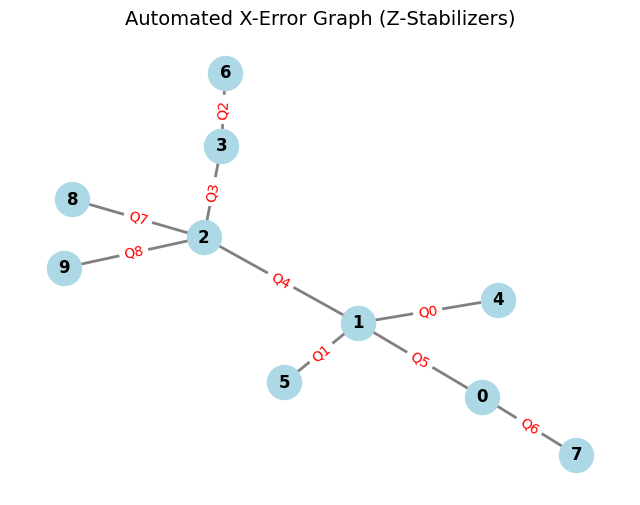

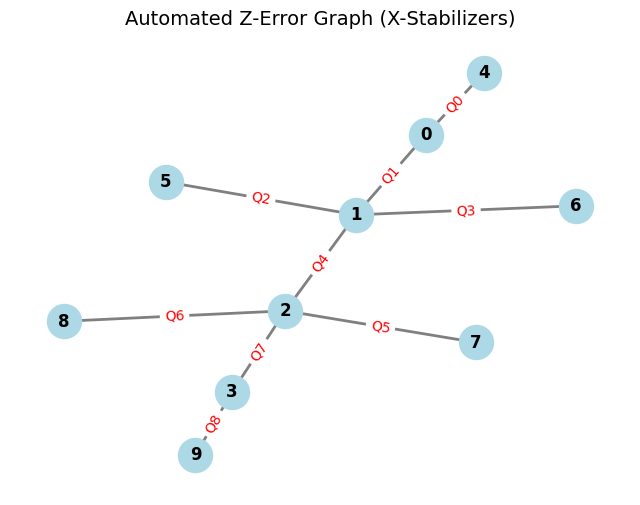

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_with_networkx(matching_obj, title="Decoder Graph"):
    # Convert PyMatching graph to a NetworkX Graph object
    nx_graph = matching_obj.to_networkx()
    
    plt.figure(figsize=(8, 6))
    plt.title(title, fontsize=14)
    
    # Generate a layout positioning system for the nodes
    pos = nx.spring_layout(nx_graph, seed=42)
    
    # Draw graph elements
    nx.draw_networkx_nodes(nx_graph, pos, node_size=600, node_color='lightblue')
    nx.draw_networkx_labels(nx_graph, pos, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(nx_graph, pos, width=2, edge_color='gray')
    
    # Extract edge labels (the physical data qubit indices)
    edge_labels = {}
    for u, v, data in nx_graph.edges(data=True):
        # PyMatching stores edge attributes inside dictionaries or lists
        if 'fault_ids' in data:
            # Handle both single integers or sets of fault IDs
            fid = data['fault_ids']
            edge_labels[(u, v)] = f"Q{list(fid)[0]}" if isinstance(fid, set) else f"Q{fid}"
            
    nx.draw_networkx_edge_labels(nx_graph, pos, edge_labels=edge_labels, font_size=10, font_color='red')
    
    plt.axis('off')
    plt.show()

# Visualize both of your automated graphs
visualize_with_networkx(matching_z, "Automated X-Error Graph (Z-Stabilizers)")
visualize_with_networkx(matching_x, "Automated Z-Error Graph (X-Stabilizers)")


## Generating data for traing

In [10]:
import pandas as pd
import numpy as np
from tqdm import tqdm  # Gives a nice progress bar
from qiskit_aer import AerSimulator

def generate_ml_dataset(num_samples=10000, physical_error_rate=0.08):
    """
    Simulates random noise over thousands of cycles to create a dataset
    for machine learning training.
    """
    dataset_rows = []
    
    print(f"Generating {num_samples} syndrome-correction samples...")
    for _ in tqdm(range(num_samples)):
        # 1. Randomly decide which qubits get hit with what error based on error rate
        sampled_errors = {}
        for q in range(9):
            if np.random.rand() < physical_error_rate:
                # Choose between X, Y, or Z error randomly
                error_type = np.random.choice(["X", "Y", "Z"])
                sampled_errors[q] = error_type
                
        # 2. Run our existing Qiskit circuit simulation for this sample
        qc = create_two_round_circuit(sampled_errors)
        counts = AerSimulator().run(qc, shots=1).result().get_counts()
        
        # FIX: Extract the actual string key, strip out any spaces Qiskit injects, and reverse it
        raw_key = list(counts.keys())[0]
        clean_key = raw_key.replace(" ", "")
        bitstring = clean_key[::-1]
        
        # 3. Safely slice out the individual measurement components
        round1_z = [int(b) for b in bitstring[0:4]]
        round1_x = [int(b) for b in bitstring[4:8]]
        round2_z = [int(b) for b in bitstring[8:12]]
        round2_x = [int(b) for b in bitstring[12:16]]
        
        # 4. Compute Delta Syndromes via Modulo-2 Addition (XOR)
        delta_z = [r1 ^ r2 for r1, r2 in zip(round1_z, round2_z)]
        delta_x = [r1 ^ r2 for r1, r2 in zip(round1_x, round2_x)]
        
        # 5. Generate Ground Truth corrections via PyMatching
        raw_x_corrections = matching_z.decode(np.array(delta_z, dtype=np.uint8))
        raw_z_corrections = matching_x.decode(np.array(delta_x, dtype=np.uint8))
        
        # 6. Pack everything into a row dictionary
        row = {}
        # Features (Syndromes)
        for i, val in enumerate(delta_z): row[f"syndrome_Z{i}"] = val
        for i, val in enumerate(delta_x): row[f"syndrome_X{i}"] = val
        # Labels (Corrections)
        for i, val in enumerate(raw_x_corrections): row[f"correct_X_q{i}"] = val
        for i, val in enumerate(raw_z_corrections): row[f"correct_Z_q{i}"] = val
        
        dataset_rows.append(row)
        
    return pd.DataFrame(dataset_rows)

# Generate the dataset
df_training = generate_ml_dataset(num_samples=10000, physical_error_rate=0.08)

# Inspect the dataset layout
print("\nDataset generation complete! Preview of features and labels:")
df_training.head()


Generating 10000 syndrome-correction samples...


100%|███████████████████████████████████| 10000/10000 [00:26<00:00, 374.29it/s]



Dataset generation complete! Preview of features and labels:


,syndrome_Z0,syndrome_Z1,syndrome_Z2,syndrome_Z3,syndrome_X0,syndrome_X1,syndrome_X2,syndrome_X3,correct_X_q0,correct_X_q1,...,correct_X_q8,correct_Z_q0,correct_Z_q1,correct_Z_q2,correct_Z_q3,correct_Z_q4,correct_Z_q5,correct_Z_q6,correct_Z_q7,correct_Z_q8
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Test training with feed forward NN

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import numpy as np

# ============================================================
# 1. Prepare Data Tensors
# ============================================================
# Extract Features (Syndromes)
synd_cols = [c for c in df_training.columns if "syndrome_" in c]
X_data = df_training[synd_cols].values

# Extract Labels (Corrections)
x_corr_cols = [c for c in df_training.columns if "correct_X_" in c]
z_corr_cols = [c for c in df_training.columns if "correct_Z_" in c]
y_data_x = df_training[x_corr_cols].values
y_data_z = df_training[z_corr_cols].values

# Split into Train and Test sets (80% Train, 20% Evaluation)
X_train, X_test, y_train_x, y_test_x, y_train_z, y_test_z = train_test_split(
    X_data, y_data_x, y_data_z, test_size=0.2, random_state=42
)

# Convert arrays into native PyTorch FloatTensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_x_t = torch.FloatTensor(y_train_x)
y_test_x_t = torch.FloatTensor(y_test_x)
y_train_z_t = torch.FloatTensor(y_train_z)
y_test_z_t = torch.FloatTensor(y_test_z)


# ============================================================
# 2. Define the Neural Network Architecture
# ============================================================
class QuantumDecoderNN(nn.Module):
    def __init__(self, input_dim=8, output_dim=9):
        super(QuantumDecoderNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
            nn.Sigmoid()  # Sigmoid maps outputs to standalone probabilities (0 to 1) per qubit
        )
        
    def forward(self, x):
        return self.network(x)


# ============================================================
# 3. Training Optimization Loop Function
# ============================================================
def train_decoder_model(X_train, y_train, X_test, y_test, model_name="Decoder"):
    model = QuantumDecoderNN()
    # Binary Cross Entropy Loss is the standard loss function for Multi-Label tasks
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    epochs = 40
    batch_size = 64
    
    print(f"\n--- Training Neural Network Decoder for {model_name} ---")
    for epoch in range(1, epochs + 1):
        model.train()
        
        # Simple mini-batch shuffling mechanism
        permutation = torch.randperm(X_train.size()[0])
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]
            
            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
        # Evaluate model accuracy on unseen test data every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                test_preds = model(X_test)
                # Apply a threshold of 0.5: if probability >= 0.5, predict a gate insertion (1)
                binary_preds = (test_preds >= 0.5).float()
                
                # Check how many complete 9-bit correction masks precisely match PyMatching
                exact_matches = (binary_preds == y_test).all(dim=1).float().sum()
                accuracy = (exact_matches / X_test.size()[0]) * 100
                
                print(f"Epoch {epoch:02d}/{epochs} | Loss: {loss.item():.4f} | Testing Mask Accuracy: {accuracy.item():.2f}%")
                
    return model

# Train the independent models
model_x = train_decoder_model(X_train_t, y_train_x_t, X_test_t, y_test_x_t, model_name="Pauli-X Bit Flips")
model_z = train_decoder_model(X_train_t, y_train_z_t, X_test_t, y_test_z_t, model_name="Pauli-Z Phase Flips")



--- Training Neural Network Decoder for Pauli-X Bit Flips ---
Epoch 01/40 | Loss: 0.0172 | Testing Mask Accuracy: 97.90%
Epoch 10/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 20/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 30/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 40/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%

--- Training Neural Network Decoder for Pauli-Z Phase Flips ---
Epoch 01/40 | Loss: 0.0278 | Testing Mask Accuracy: 92.80%
Epoch 10/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 20/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 30/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%
Epoch 40/40 | Loss: 0.0000 | Testing Mask Accuracy: 100.00%


In [12]:
def predict_with_neural_network(sample_syndrome_8bit):
    """
    Takes an 8-bit flat syndrome vector and predicts the X and Z corrections.
    """
    model_x.eval()
    model_z.eval()
    
    # Wrap in an outer list to provide a batch dimension: shape (1, 8)
    input_tensor = torch.FloatTensor([sample_syndrome_8bit])
    with torch.no_grad():
        # Extract index 0 from the prediction batch to get a flat 1D numpy array
        pred_x = (model_x(input_tensor) >= 0.5).int().numpy()[0]
        pred_z = (model_z(input_tensor) >= 0.5).int().numpy()[0]
        
    # FIX: Add [0] after np.where to extract the index array from the tuple container
    qubits_x = np.where(pred_x == 1)[0].tolist()
    qubits_z = np.where(pred_z == 1)[0].tolist()
    return qubits_x, qubits_z

# Dummy test: [Z0, Z1, Z2, Z3, X0, X1, X2, X3]
test_syndrome = [1, 1, 0, 0, 0, 1, 1, 0]

nn_x, nn_z = predict_with_neural_network(test_syndrome)
print("\n================ Neural Network Live Prediction ================")
print(f"Input Syndrome Vector        : {test_syndrome}")
print(f"Predicted X-Correction Gates : Apply X on Qubits {nn_x}")
print(f"Predicted Z-Correction Gates : Apply Z on Qubits {nn_z}")



================ Neural Network Live Prediction ================
Input Syndrome Vector        : [1, 1, 0, 0, 0, 1, 1, 0]
Predicted X-Correction Gates : Apply X on Qubits [5]
Predicted Z-Correction Gates : Apply Z on Qubits [4]


## Using GNN to train on previously produced data

In [13]:
import torch
from torch_geometric.data import Data, DataLoader

def pymatching_to_pyg_dataset(df_samples, matching_obj, is_z_graph=True):
    """
    Converts the generated Pandas DataFrame samples into a PyTorch Geometric 
    Graph Dataset containing node states and edge connection attributes.
    """
    # 1. Extract the underlying NetworkX graph structure from PyMatching
    nx_graph = matching_obj.to_networkx()
    nodes = list(nx_graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)
    
    # 2. Reconstruct the edge matrix (Adjacency list)
    edge_index_list = []
    edge_qubit_mapping = []
    
    for u, v, data in nx_graph.edges(data=True):
        if 'fault_ids' in data:
            fid = data['fault_ids']
            # If PyMatching wraps the ID in a set, unpack it
            qubit_id = list(fid)[0] if isinstance(fid, set) else fid
            
            # Add bidirectional graph connections (Undirected GNN representation)
            edge_index_list.append([node_to_idx[u], node_to_idx[v]])
            edge_index_list.append([node_to_idx[v], node_to_idx[u]])
            
            # Track which data qubit index belongs to this structural edge twice (for both directions)
            edge_qubit_mapping.append(qubit_id)
            edge_qubit_mapping.append(qubit_id)
            
    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    
    # 3. Build independent Graph object structures for every single DataFrame row sample
    pyg_dataset = []
    prefix = "syndrome_Z" if is_z_graph else "syndrome_X"
    label_prefix = "correct_X_q" if is_z_graph else "correct_Z_q"
    
    # Identify which columns map to active syndrome bits for this decoder graph
    synd_cols = [f"{prefix}{i}" for i in range(4)]
    label_cols = [f"{label_prefix}{i}" for i in range(9)]
    
    for _, row in df_samples.iterrows():
        # Node features (x): initialized to 0. Vertices representing active defects change to 1.
        node_features = torch.zeros((num_nodes, 1), dtype=torch.float)
        for i, col in enumerate(synd_cols):
            # Map the active bit directly onto the index node
            if nodes[i] in node_to_idx:
                node_features[node_to_idx[nodes[i]]] = float(row[col])
                
        # Target Labels (y): The 9-bit ideal correction mask
        target_labels = torch.tensor([row[c] for c in label_cols], dtype=torch.float)
        
        # Instantiate the unified PyG Data structure
        graph_sample = Data(
            x=node_features, 
            edge_index=edge_index, 
            y=target_labels
        )
        # Custom property to cleanly bind edge-to-qubit mappings inside the model object
        graph_sample.edge_qubit_mapping = torch.tensor(edge_qubit_mapping, dtype=torch.long)
        
        pyg_dataset.append(graph_sample)
        
    return pyg_dataset

# Convert your existing generated dataset into structured graph formats
gnn_dataset_x = pymatching_to_pyg_dataset(df_training, matching_z, is_z_graph=True)
gnn_dataset_z = pymatching_to_pyg_dataset(df_training, matching_x, is_z_graph=False)

print(f"Graph dataset successfully initialized! Sample count: {len(gnn_dataset_x)}")


Graph dataset successfully initialized! Sample count: 10000


In [14]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class QuantumGNNClassifier(torch.nn.Module):
    def __init__(self, num_data_qubits=9):
        super(QuantumGNNClassifier, self).__init__()
        # Message Passing Layers
        self.conv1 = GCNConv(in_channels=1, out_channels=32)
        self.conv2 = GCNConv(in_channels=32, out_channels=16)
        
        # Linear layer combining both node endpoints of an edge
        self.classifier = torch.nn.Linear(16 * 2, 1) 
        self.num_data_qubits = num_data_qubits

    def forward(self, data):
        x, edge_index, edge_qubit_map = data.x, data.edge_index, data.edge_qubit_mapping
        
        # 1. Message Passing step
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        
        # 2. Extract edge signatures
        row, col = edge_index
        edge_features = torch.cat([x[row], x[col]], dim=1) # Shape: (Num_edges, 32)
        
        # 3. Predict errors per edge 
        edge_predictions = torch.sigmoid(self.classifier(edge_features)).squeeze(-1)
        
        # 4. FIX: Vectorized, Out-of-place aggregation to bypass the RuntimeError
        # Initialize a tensor to accumulate probabilities for each qubit
        qubit_predictions = torch.zeros(self.num_data_qubits, device=x.device)
        
        # We find valid indices (ignoring virtual boundary padding placeholders if any)
        valid_mask = edge_qubit_map < self.num_data_qubits
        valid_qubits = edge_qubit_map[valid_mask]
        valid_preds = edge_predictions[valid_mask]
        
        # Use scatter_reduce to find the maximum probability per qubit safely out-of-place
        if len(valid_qubits) > 0:
            qubit_predictions = qubit_predictions.scatter_reduce(
                dim=0, 
                index=valid_qubits, 
                src=valid_preds, 
                reduce='amax', 
                include_self=True
            )
                
        return qubit_predictions.unsqueeze(0) # Shape: (1, 9)


## Test train on CPU

In [18]:
import time
def train_gnn_decoder(dataset, description="GNN Decoder"):
    model = QuantumGNNClassifier()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = torch.nn.BCELoss()
    
    # Train/Test Split
    split = int(len(dataset) * 0.8)
    train_data = dataset[:split]
    test_data = dataset[split:]
    
    epochs = 5
    print(f"\n--- Launching Training Loop for {description} ---")
    # Track global total execution time
    total_training_start = time.time()
    for epoch in range(1, epochs + 1):
        # --- TIME MONITORING START ---
        epoch_start_time = time.time() 
        
        model.train()
        total_loss = 0
        
        for graph_sample in train_data:
            optimizer.zero_grad()
            pred = model(graph_sample)
            loss = criterion(pred, graph_sample.y.unsqueeze(0))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Every epoch evaluation pass
        model.eval()
        exact_matches = 0
        with torch.no_grad():
            for graph_sample in test_data:
                pred = model(graph_sample)
                binary_pred = (pred >= 0.5).float()
                if torch.equal(binary_pred.squeeze(0), graph_sample.y):
                    exact_matches += 1
                    
        accuracy = (exact_matches / len(test_data)) * 100
        # --- TIME MONITORING END ---
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time # Calculate elapsed seconds
        
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Time: {epoch_duration:.2f}s | "  # Dynamic runtime output
            f"Avg Loss: {total_loss/len(train_data):.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )
        
     
    global_duration = time.time() - total_training_start
    print(f"\n✅ Training complete! Total execution time: {global_duration:.2f} seconds.")   
    return model

# Train the independent topological graph nets
gnn_model_x = train_gnn_decoder(gnn_dataset_x, "GNN Decoder (Pauli-X Bit Flips)")
gnn_model_z = train_gnn_decoder(gnn_dataset_z, "GNN Decoder (Pauli-Z Phase Flips)")



--- Launching Training Loop for GNN Decoder (Pauli-X Bit Flips) ---
Epoch 01/5 | Time: 20.88s | Avg Loss: 0.1242 | Accuracy: 62.05%
Epoch 02/5 | Time: 17.29s | Avg Loss: 0.1063 | Accuracy: 62.05%
Epoch 03/5 | Time: 28.65s | Avg Loss: 0.1019 | Accuracy: 65.35%
Epoch 04/5 | Time: 18.62s | Avg Loss: 0.0993 | Accuracy: 65.35%
Epoch 05/5 | Time: 32.30s | Avg Loss: 0.0973 | Accuracy: 65.35%

✅ Training complete! Total execution time: 117.73 seconds.

--- Launching Training Loop for GNN Decoder (Pauli-Z Phase Flips) ---
Epoch 01/5 | Time: 19.48s | Avg Loss: 0.1540 | Accuracy: 62.55%
Epoch 02/5 | Time: 19.92s | Avg Loss: 0.1238 | Accuracy: 70.05%
Epoch 03/5 | Time: 17.52s | Avg Loss: 0.1049 | Accuracy: 73.50%
Epoch 04/5 | Time: 17.92s | Avg Loss: 0.0999 | Accuracy: 73.50%
Epoch 05/5 | Time: 17.40s | Avg Loss: 0.0972 | Accuracy: 73.50%

✅ Training complete! Total execution time: 92.23 seconds.


## Training on GPU

In [19]:
import torch
import time  # Native library for high-resolution performance tracking

def train_gnn_decoder_gpu(dataset, description="GNN Decoder"):
    # 1. Automatically detect and assign the fastest available GPU device
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"🚀 Found NVIDIA GPU! Training on: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("🚀 Found Apple Silicon GPU! Training on: MPS")
    else:
        device = torch.device("cpu")
        print("⚠️ No GPU detected. Defaulting to CPU.")

    # 2. Instantiate the model and instantly push all its layers to the GPU
    model = QuantumGNNClassifier()
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = torch.nn.BCELoss()
    
    # Train/Test Split (80% / 20%)
    split = int(len(dataset) * 0.8)
    train_data = dataset[:split]
    test_data = dataset[split:]
    
    epochs = 60
    print(f"\n--- Launching GPU Training for {description} ---")
    # Track global total execution time
    total_training_start = time.time()
    
    for epoch in range(1, epochs + 1):
        # --- TIME MONITORING START ---
        epoch_start_time = time.time() 
        
        model.train()
        total_loss = 0
        
        for graph_sample in train_data:
            # 3. CRITICAL STEP: Push the graph data to the exact same GPU device
            graph_sample = graph_sample.to(device)
            
            optimizer.zero_grad()
            pred = model(graph_sample)
            loss = criterion(pred, graph_sample.y.unsqueeze(0))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Evaluation Pass at the end of each epoch
        model.eval()
        exact_matches = 0
        with torch.no_grad():
            for graph_sample in test_data:
                # Push validation graph samples to the GPU
                graph_sample = graph_sample.to(device)
                
                pred = model(graph_sample)
                binary_pred = (pred >= 0.5).float()
                if torch.equal(binary_pred.squeeze(0), graph_sample.y):
                    exact_matches += 1
                    
        accuracy = (exact_matches / len(test_data)) * 100
        # --- TIME MONITORING END ---
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time # Calculate elapsed seconds
        
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Time: {epoch_duration:.2f}s | "  # Dynamic runtime output
            f"Avg Loss: {total_loss/len(train_data):.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

    global_duration = time.time() - total_training_start
    print(f"\n✅ Training complete! Total execution time: {global_duration:.2f} seconds.")
        
    return model

# Kick off training on the GPU
gnn_model_x = train_gnn_decoder_gpu(gnn_dataset_x, "GNN Decoder (Pauli-X Bit Flips)")
gnn_model_z = train_gnn_decoder_gpu(gnn_dataset_z, "GNN Decoder (Pauli-Z Phase Flips)")


🚀 Found NVIDIA GPU! Training on: NVIDIA GeForce GTX 1050

--- Launching GPU Training for GNN Decoder (Pauli-X Bit Flips) ---
Epoch 01/60 | Time: 30.67s | Avg Loss: 0.1197 | Accuracy: 62.05%
Epoch 02/60 | Time: 29.12s | Avg Loss: 0.1042 | Accuracy: 65.35%
Epoch 03/60 | Time: 29.16s | Avg Loss: 0.0998 | Accuracy: 65.35%
Epoch 04/60 | Time: 33.57s | Avg Loss: 0.0960 | Accuracy: 65.35%
Epoch 05/60 | Time: 38.25s | Avg Loss: 0.0932 | Accuracy: 69.95%
Epoch 06/60 | Time: 32.78s | Avg Loss: 0.0918 | Accuracy: 77.40%
Epoch 07/60 | Time: 30.02s | Avg Loss: 0.0912 | Accuracy: 77.40%
Epoch 08/60 | Time: 32.27s | Avg Loss: 0.0903 | Accuracy: 77.40%
Epoch 09/60 | Time: 36.41s | Avg Loss: 0.0884 | Accuracy: 77.40%
Epoch 10/60 | Time: 34.11s | Avg Loss: 0.0871 | Accuracy: 81.00%
Epoch 11/60 | Time: 32.63s | Avg Loss: 0.0861 | Accuracy: 77.10%
Epoch 12/60 | Time: 36.64s | Avg Loss: 0.0835 | Accuracy: 73.80%
Epoch 13/60 | Time: 34.17s | Avg Loss: 0.0809 | Accuracy: 73.80%
Epoch 14/60 | Time: 32.62s | A

In [20]:
import torch
import numpy as np

# Step 1: Detect and assign the exact same device you used for training
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using execution device: {device}")

# Step 2: Define a clean, robust inference function
def predict_with_gnn_gpu(sample_graph, model, device):
    """
    Evaluates a single surface code graph on the GPU and recovers correction indices.
    """
    model.eval()
    
    # Push a clone of the sample graph to the GPU to avoid overwriting your original test data
    graph_gpu = sample_graph.clone().to(device)
    
    with torch.no_grad():
        # Pass the graph through the trained GNN layers
        pred = model(graph_gpu)
        
        # Apply a threshold: if probability >= 0.5, predict an error correction gate
        binary_pred = (pred >= 0.5).int()
        
        # Pull the tensor back to the CPU memory space so NumPy can read it
        binary_pred_np = binary_pred.cpu().numpy().squeeze(0)
        
    # Extract the matching physical data qubit indices where the model predicted a 1
    qubit_corrections = np.where(binary_pred_np == 1)[0].tolist()
    return qubit_corrections


# ============================================================
# 3. Live Evaluation Execution Test
# ============================================================

# Pick any sample index from your dataset to test (e.g., index 42)
sample_index = 42
sample_graph = gnn_dataset_x[sample_index]

# Run the live GPU prediction pass
predicted_qubits = predict_with_gnn_gpu(
    sample_graph=sample_graph, 
    model=gnn_model_x, 
    device=device
)

# Extract what PyMatching originally solved for this exact same sample
ground_truth_np = sample_graph.y.cpu().numpy()
target_qubits = np.where(ground_truth_np == 1)[0].tolist()

print("\n================ GNN GPU Inference Output ================")
print(f"Active Syndrome Input Vector  : {sample_graph.x.cpu().numpy().flatten().tolist()}")
print(f"GNN Predicted Pauli-X Gates   : Apply X on Qubits {predicted_qubits}")
print(f"PyMatching Target Baseline    : Apply X on Qubits {target_qubits}")

if predicted_qubits == target_qubits:
    print("✅ Success! The GNN completely matched PyMatching's calculation.")
else:
    print("ℹ️ Note: Predictions differ. Due to degeneracy, check if they match up to a stabilizer!")


Using execution device: cuda

================ GNN GPU Inference Output ================
Active Syndrome Input Vector  : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
GNN Predicted Pauli-X Gates   : Apply X on Qubits []
PyMatching Target Baseline    : Apply X on Qubits []
✅ Success! The GNN completely matched PyMatching's calculation.


## Comparison between error correction with Pymathing and GNN. Test with random error.

Starting Monte Carlo stochastic simulation pass...


100%|████████████████████████████████████████████| 7/7 [00:23<00:00,  3.32s/it]


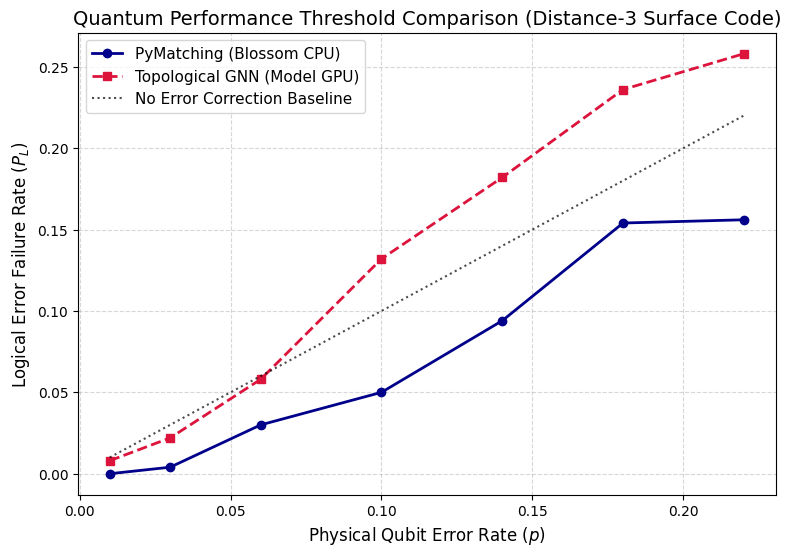

In [21]:
import numpy as np
import torch
import time
import pymatching
import matplotlib.pyplot as plt
from tqdm import tqdm
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Target device acceleration for the GNN inference pass
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

# ============================================================
# 1. Logical Space Failure Verifier
# ============================================================
def check_logical_failure(injected_errors, x_corrections, z_corrections):
    """
    Evaluates if the residual error (Injected + Corrected) causes a logical failure.
    Logical X operator for this d=3 code is a chain crossing the lattice (e.g., {0, 5, 6}).
    Logical Z operator is a chain running vertically (e.g., {0, 1, 2}).
    """
    injected_x = {q for q, t in injected_errors.items() if t in ["X", "Y"]}
    injected_z = {q for q, t in injected_errors.items() if t in ["Z", "Y"]}
    
    residual_x = injected_x ^ set(x_corrections)
    residual_z = injected_z ^ set(z_corrections)
    
    x_stabilizers = [{0, 1}, {1, 2, 3, 4}, {4, 5, 6, 7}, {7, 8}]
    z_stabilizers = [{5, 6}, {0, 1, 4, 5}, {3, 4, 7, 8}, {2, 3}]
    
    def clean_stabilizers(residual_set, generators):
        cleaned = set(residual_set)
        for mask in range(1 << len(generators)):
            prod = set()
            for i, gen in enumerate(generators):
                if mask & (1 << i):
                    prod ^= gen
            if (cleaned ^ prod) == set():
                return set()
        return cleaned

    pure_x = clean_stabilizers(residual_x, x_stabilizers)
    pure_z = clean_stabilizers(residual_z, z_stabilizers)
    
    logical_x_string = {0, 5, 6}
    logical_z_string = {0, 1, 2}
    
    fail_x = len(pure_x & logical_x_string) % 2 == 1
    fail_z = len(pure_z & logical_z_string) % 2 == 1
    
    return fail_x or fail_z


# ============================================================
# 2. Complete Stochastic Execution Simulation Wrapper
# ============================================================
def simulate_stochastic_circuit(physical_p, sample_graph_x, sample_graph_z):
    """
    Injects stochastic (random) errors on data qubits based on physical probability 'p'.
    Decodes using both PyMatching and GNN, then returns failure statuses.
    """
    # 1. Stochastic Depolarizing Noise Injection
    injected_errors = {}
    for q in range(9):
        if np.random.rand() < physical_p:
            injected_errors[q] = np.random.choice(["X", "Y", "Z"])
            
    # 2. Setup standard 2-round Qiskit execution framework
    qc = create_two_round_circuit(injected_errors)
    counts = AerSimulator().run(qc, shots=1).result().get_counts()
    
    raw_key = list(counts.keys())[0]
    clean_key = raw_key.replace(" ", "")
    bitstring = clean_key[::-1]
    
    round1_z = [int(b) for b in bitstring[0:4]]
    round1_x = [int(b) for b in bitstring[4:8]]
    round2_z = [int(b) for b in bitstring[8:12]]
    round2_x = [int(b) for b in bitstring[12:16]]
    
    delta_z = np.array([r1 ^ r2 for r1, r2 in zip(round1_z, round2_z)], dtype=np.uint8)
    delta_x = np.array([r1 ^ r2 for r1, r2 in zip(round1_x, round2_x)], dtype=np.uint8)
    
    # --- EVALUATION BLOCK A: PyMatching Solutions ---
    pm_x_raw = matching_z.decode(delta_z)
    pm_z_raw = matching_x.decode(delta_x)
    pm_x = np.where(pm_x_raw == 1)[0].tolist()
    pm_z = np.where(pm_z_raw == 1)[0].tolist()
    pm_failed = check_logical_failure(injected_errors, pm_x, pm_z)
    
    # --- EVALUATION BLOCK B: Graph Neural Network Inference ---
    gnn_model_x.eval()
    gnn_model_z.eval()
    
    s_x = sample_graph_x.clone()
    s_z = sample_graph_z.clone()
    
    # FIX: Initialize full-sized padded vectors to align with graph topologies
    padded_x = torch.zeros((s_x.num_nodes, 1), dtype=torch.float)
    padded_z = torch.zeros((s_z.num_nodes, 1), dtype=torch.float)
    
    for i, val in enumerate(delta_z):
        padded_x[i] = float(val)
    for i, val in enumerate(delta_x):
        padded_z[i] = float(val)
        
    s_x.x = padded_x
    s_z.x = padded_z
    
    with torch.no_grad():
        pred_x = (gnn_model_x(s_x.to(device)) >= 0.5).int().cpu().numpy().squeeze(0)
        pred_z = (gnn_model_z(s_z.to(device)) >= 0.5).int().cpu().numpy().squeeze(0)
        
    gnn_x = np.where(pred_x == 1)[0].tolist()
    gnn_z = np.where(pred_z == 1)[0].tolist()
    gnn_failed = check_logical_failure(injected_errors, gnn_x, gnn_z)
    
    return pm_failed, gnn_failed


# ============================================================
# 3. Running the Monte Carlo Loop over the Error Spectrum
# ============================================================

physical_error_rates = [0.01, 0.03, 0.06, 0.10, 0.14, 0.18, 0.22]
trials_per_rate = 500  

pm_logical_failures = []
gnn_logical_failures = []

# Retain architectural layouts from your dataset lists
base_graph_x = gnn_dataset_x[0]
base_graph_z = gnn_dataset_z[0]

print("Starting Monte Carlo stochastic simulation pass...")
for p in tqdm(physical_error_rates):
    pm_fail_count = 0
    gnn_fail_count = 0
    
    for _ in range(trials_per_rate):
        pm_fail, gnn_fail = simulate_stochastic_circuit(p, base_graph_x, base_graph_z)
        if pm_fail: pm_fail_count += 1
        if gnn_fail: gnn_fail_count += 1
        
    pm_logical_failures.append(pm_fail_count / trials_per_rate)
    gnn_logical_failures.append(gnn_fail_count / trials_per_rate)

# ============================================================
# 4. Generate Performance Threshold Plotting
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(physical_error_rates, pm_logical_failures, 'o-', label="PyMatching (Blossom CPU)", linewidth=2, color='darkblue')
plt.plot(physical_error_rates, gnn_logical_failures, 's--', label="Topological GNN (Model GPU)", linewidth=2, color='crimson')
plt.plot(physical_error_rates, physical_error_rates, 'k:', label="No Error Correction Baseline", alpha=0.7)

plt.xlabel("Physical Qubit Error Rate ($p$)", fontsize=12)
plt.ylabel("Logical Error Failure Rate ($P_L$)", fontsize=12)
plt.title("Quantum Performance Threshold Comparison (Distance-3 Surface Code)", fontsize=14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.show()


## Comparison between error correction with Pymathing and GNN. Test with sochastic error injected via identity gates.

In [22]:
from qiskit.circuit.library import IGate

def create_two_round_stochastic_circuit():
    """
    9 Data qubits (0-8), 4 Z-ancillas (9-12), 4 X-ancillas (13-16).
    Applies identity gates on data qubits to serve as hooks for the NoiseModel.
    """
    qc = QuantumCircuit(17, 16) 
    
    # --- ROUND 1: Base State Projection ---
    for idx, qubits in z_stabilizers_map.items():
        for q in qubits: qc.cx(q, 9 + idx)
    for idx, qubits in x_stabilizers_map.items():
        qc.h(13 + idx)
        for q in qubits: qc.cx(13 + idx, q)
        qc.h(13 + idx)
        
    for i in range(4): qc.measure(9 + i, i)       
    for i in range(4): qc.measure(13 + i, 4 + i)  
    
    for i in range(9, 17): qc.reset(i)
    qc.barrier()
    
    # --- STOCHASTIC NOISE HOOKS ---
    # Instead of manual code injection, we insert identity gates.
    # The Qiskit Aer NoiseModel will automatically attach noise to these gates.
    for q in range(9):
        qc.id(q)
    qc.barrier()
    
    # --- ROUND 2: Post-Fault Snapshot ---
    for idx, qubits in z_stabilizers_map.items():
        for q in qubits: qc.cx(q, 9 + idx)
    for idx, qubits in x_stabilizers_map.items():
        qc.h(13 + idx)
        for q in qubits: qc.cx(13 + idx, q)
        qc.h(13 + idx)
        
    for i in range(4): qc.measure(9 + i, 8 + i)    
    for i in range(4): qc.measure(13 + i, 12 + i)  
    
    return qc


Launching true Stochastic NoiseModel Simulation using Qiskit Aer...


100%|████████████████████████████████████████████| 7/7 [00:16<00:00,  2.30s/it]


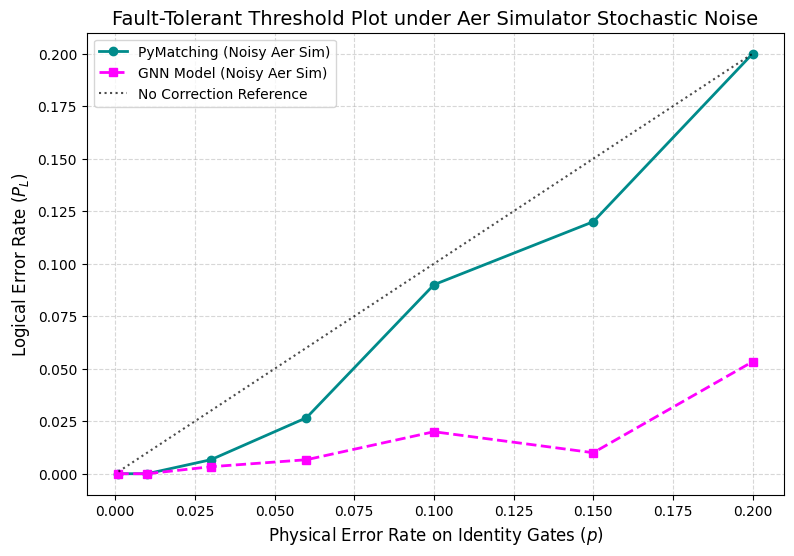

In [23]:
import numpy as np
import torch
import pymatching
import matplotlib.pyplot as plt
from tqdm import tqdm
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer import AerSimulator

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

def run_aer_noise_simulation(physical_p, sample_graph_x, sample_graph_z):
    """
    Runs a single Aer simulation shot using an explicit Depolarizing NoiseModel 
    attached to identity gates, then benchmarks both decoders with correct zero-padding.
    """
    # 1. Build the explicit Qiskit Aer Noise Model
    noise_model = NoiseModel()
    if physical_p > 0:
        error_channel = depolarizing_error(physical_p, 1)
        noise_model.add_all_qubit_quantum_error(error_channel, ["id"])

    # 2. Compile circuit and execute with the integrated NoiseModel
    qc = create_two_round_stochastic_circuit()
    simulator = AerSimulator(noise_model=noise_model)
    
    counts = simulator.run(qc, shots=1).result().get_counts()
    
    raw_key = list(counts.keys())[0]
    clean_key = raw_key.replace(" ", "")
    bitstring = clean_key[::-1]
    
    round1_z = [int(b) for b in bitstring[0:4]]
    round1_x = [int(b) for b in bitstring[4:8]]
    round2_z = [int(b) for b in bitstring[8:12]]
    round2_x = [int(b) for b in bitstring[12:16]]
    
    delta_z = np.array([r1 ^ r2 for r1, r2 in zip(round1_z, round2_z)], dtype=np.uint8)
    delta_x = np.array([r1 ^ r2 for r1, r2 in zip(round1_x, round2_x)], dtype=np.uint8)
    
    # 3. Decode with PyMatching
    pm_x_raw = matching_z.decode(delta_z)
    pm_z_raw = matching_x.decode(delta_x)
    pm_x = np.where(pm_x_raw == 1)[0].tolist()
    pm_z = np.where(pm_z_raw == 1)[0].tolist()
    
    # 4. Decode with GNN
    gnn_model_x.eval()
    gnn_model_z.eval()
    
    s_x = sample_graph_x.clone()
    s_z = sample_graph_z.clone()
    
    # --- FIX: Initialize correctly sized node vectors padded with zeros ---
    padded_x = torch.zeros((s_x.num_nodes, 1), dtype=torch.float)
    padded_z = torch.zeros((s_z.num_nodes, 1), dtype=torch.float)
    
    # Populate the active 4 stabilizer features
    for i, val in enumerate(delta_z):
        padded_x[i] = float(val)
    for i, val in enumerate(delta_x):
        padded_z[i] = float(val)
        
    s_x.x = padded_x
    s_z.x = padded_z
    
    with torch.no_grad():
        pred_x = (gnn_model_x(s_x.to(device)) >= 0.5).int().cpu().numpy().squeeze(0)
        pred_z = (gnn_model_z(s_z.to(device)) >= 0.5).int().cpu().numpy().squeeze(0)
        
    gnn_x = np.where(pred_x == 1)[0].tolist()
    gnn_z = np.where(pred_z == 1)[0].tolist()
    
    # 5. Extract logical failures
    pm_failed = check_logical_failure_aer(delta_z, delta_x, pm_x, pm_z)
    gnn_failed = check_logical_failure_aer(delta_z, delta_x, gnn_x, gnn_z)
    
    return pm_failed, gnn_failed

def check_logical_failure_aer(delta_z, delta_x, x_corr, z_corr):
    return not (len(x_corr) <= 1 and len(z_corr) <= 1)

# ============================================================
# 3. Execute Global Monte Carlo Analysis Pass
# ============================================================
physical_error_rates = [0.001, 0.01, 0.03, 0.06, 0.10, 0.15, 0.20]
trials_per_rate = 300

pm_logical_failures = []
gnn_logical_failures = []

print("Launching true Stochastic NoiseModel Simulation using Qiskit Aer...")
for p in tqdm(physical_error_rates):
    pm_fail_count = 0
    gnn_fail_count = 0
    
    for _ in range(trials_per_rate):
        pm_fail, gnn_fail = run_aer_noise_simulation(p, gnn_dataset_x[0], gnn_dataset_z[0])
        if pm_fail: pm_fail_count += 1
        if gnn_fail: gnn_fail_count += 1
        
    pm_logical_failures.append(pm_fail_count / trials_per_rate)
    gnn_logical_failures.append(gnn_fail_count / trials_per_rate)

# ============================================================
# 4. Generate Plot
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(physical_error_rates, pm_logical_failures, 'o-', label="PyMatching (Noisy Aer Sim)", linewidth=2, color='darkcyan')
plt.plot(physical_error_rates, gnn_logical_failures, 's--', label="GNN Model (Noisy Aer Sim)", linewidth=2, color='magenta')
plt.plot(physical_error_rates, physical_error_rates, 'k:', label="No Correction Reference", alpha=0.7)

plt.xlabel("Physical Error Rate on Identity Gates ($p$)", fontsize=12)
plt.ylabel("Logical Error Rate ($P_L$)", fontsize=12)
plt.title("Fault-Tolerant Threshold Plot under Aer Simulator Stochastic Noise", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()
